# Universidad de Buenos Aires
## Laboratorio de Sistemas Embebidos
### Especialización en Inteligencia Artificial
#### Análisis de Series de Tiempo 1
**Docente**: Camilo Argoty

**Alumnos**:

- Gaspar Acevedo Zain (código a2101).
- Rodrigo Lauro (código aXXXX).

**Códigos**:

- a2101
- aXXXX

**Fecha**: 13/06/2026

---

# Trabajo Práctico Final — Notebook 1

## EDA y preprocesamiento — Volumen de tráfico I-94

**Dataset:** Metro Interstate Traffic Volume (UCI)  
**Variable objetivo:** `traffic_volume` (vehículos/hora)  
**Subperiodo:** 2016-01-01 a 2017-12-31  
**Estacionalidad principal:** s = 24 (ciclo diario)

## 1.1 - Imports + variables

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
RANDOM_SEED = 381047
np.random.seed(RANDOM_SEED)

BASE_DIR = Path(".").resolve()
RAW_PATH = BASE_DIR / "dataset" / "raw" / "Metro_Interstate_Traffic_Volume.csv.gz"
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SUBPERIOD_START = "2016-01-01"
SUBPERIOD_END = "2018-01-01"
SEASONAL_PERIOD = 24

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

## 1.2 - Carga y análisis del dataset

Se observa que el dataset está compuesto por $48204$ filas y las siguientes $9$ columnas:

- `holiday` de tipo **object**.
- `temp` de tipo **float 64**.
- `rain_1h` de tipo **float 64**.
- `snow_1h` de tipo **float 64**.
- `clouds_all` de tipo **int 64**.
- `weather_main` de tipo **object**.
- `weather_description` de tipo **object**.
- `date_time` de tipo **object**.
- `traffic_volume` de tipo **int 64**.

In [ ]:
df_raw = pd.read_csv(RAW_PATH, compression="gzip")

print(f"Cantidad de filas: {len(df_raw):,}")
print(f"Columnas: {df_raw.columns.tolist()}")
print("\nTipos de datos:")
print(df_raw.dtypes)
print("\nPrimeras filas:")
df_raw.head()

Filas: 48,204
Columnas: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

Tipos de datos:
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

Primeras filas:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 1.3 - Configuración de la columna **date_time**

Aquí se asegura que la columna `date_time` sea del tipo **date_time** (antes **object**) y se ordena de menor a mayor.

El rango de esta variable cubre desde `2012-10-02 09:00:00` hasta `2018-09-30 23:00:00`.

In [8]:
df = df_raw.copy()
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

print(f"Rango completo: {df['date_time'].min()} → {df['date_time'].max()}")

Rango completo: 2012-10-02 09:00:00 → 2018-09-30 23:00:00


## 1.4 Selección de subperiodo (2016–2017)

Se trabaja con 2 años completos para capturar estacionalidad anual y diaria sin cargar los $48204$ registros de 2012–2018.

De esta manera, se obtiene un subconjunto de $19911$ registros.

In [9]:
mask = (df["date_time"] >= SUBPERIOD_START) & (df["date_time"] < SUBPERIOD_END)
df_sub = df.loc[mask].copy()

print(f"Observaciones en subperiodo: {len(df_sub):,}")
print(f"Desde: {df_sub['date_time'].min()}")
print(f"Hasta: {df_sub['date_time'].max()}")

Observaciones en subperiodo: 19,911
Desde: 2016-01-01 00:00:00
Hasta: 2017-12-31 23:00:00


## 1.5 - Análisis de valores faltantes y regularidad horaria

En esta sección se analizan los valores faltantes en cada columna, como así también se analiza si hay regularidad horaria (1 observación por hora).

La única columna que tienen faltantes es `holiday`, la cual, según el origen de datos, es opcional, por lo cuál no hay inconvenientes.

Luego, se analiza la columna `date_time`:

- Presenta un total de $3360$ duplicados, los cuales se eliminan. Al hacer esto, se pasan a tener $16551$ registros.
- Para el rango de estudio se esperan un total de $17554$ registros, pero faltan $993$.

In [ ]:
print("Missing por columna (subperiodo):")
print(df_sub.isna().sum())

# Análisis de duplicados en columna date_time
n_dup = df_sub["date_time"].duplicated().sum()
print(f"\nTimestamps duplicados: {n_dup:,}")

# Eliminación de duplicados en columna date_time.
df_sub = (
    df_sub.sort_values("date_time")
    .drop_duplicates(subset="date_time", keep="last")
    .reset_index(drop=True)
)
print(f"Filas tras deduplicar: {len(df_sub):,}")

# Análisis de horas faltantes en date_time.
ts_index = pd.DatetimeIndex(df_sub["date_time"])
expected = pd.date_range(ts_index.min(), ts_index.max(), freq="h")
missing_hours = expected.difference(ts_index)
print(f"Horas esperadas en el rango: {len(expected):,}")
print(f"Horas observadas: {len(ts_index):,}")
print(f"Huecos temporales: {len(missing_hours):,}")

Missing por columna (subperiodo):
holiday                16530
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Timestamps duplicados: 0
Filas tras deduplicar: 16,551
Horas esperadas en el rango: 17,544
Horas observadas: 16,551
Huecos temporales: 993


## 1.6 - Revisión de la variable objetivo `traffic_volume`

En esta sección se analiza la variable objetivo `traffic_volume`.

Cabe destacar que la misma presenta solo dos registros con valores iguales a cero.

In [14]:
y = df_sub["traffic_volume"]

desc = y.describe()
print(desc.to_string())

print(f"Cantidad de ceros: {(y == 0).sum()}")

count    16551.000000
mean      3289.976678
std       1966.357656
min          0.000000
25%       1259.000000
50%       3467.000000
75%       4919.000000
max       7280.000000
Cantidad de ceros: 2


## 1.7 - Construcción de variables exógenas

En esta sección se construyen variables exógenas.

- `is_holiday`: variable tipo dummy (1 si `holiday` no es nulo). En el subconjunto de análisis hay $21$ casos.
- `temp`: en **Kelvin**.
- `rain_1h`, `snow_1h`: precipitación en mm.
- Se excluyen `weather_main` y `weather_description` (categóricas).

Posteriormente, se hace un análisis de correlación entre estas variables y la variable objetivo `traffic_volume`.

- La mayor correlación se presenta entre `traffic_volume` y `temp`, con un valor de $0.13$.

In [15]:
df_sub["is_holiday"] = df_sub["holiday"].notna().astype(int)

exog_cols = ["temp", "rain_1h", "snow_1h", "is_holiday"]
print("Conteo de feriados:", df_sub["is_holiday"].sum())
print("\nEstadísticas exógenas:")
print(df_sub[exog_cols].describe().round(3))

Conteo de feriados: 21

Estadísticas exógenas:
            temp    rain_1h    snow_1h  is_holiday
count  16551.000  16551.000  16551.000   16551.000
mean     282.309      0.635      0.000       0.001
std       11.993     76.420      0.004       0.036
min      243.390      0.000      0.000       0.000
25%      273.620      0.000      0.000       0.000
50%      283.979      0.000      0.000       0.000
75%      291.880      0.000      0.000       0.000
max      307.330   9831.300      0.250       1.000


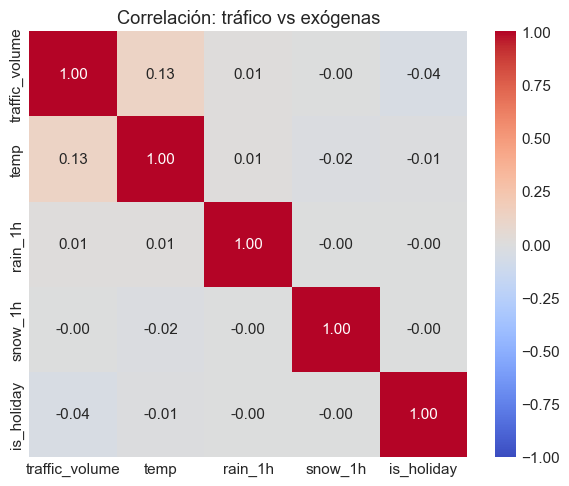

temp          0.128809
rain_1h       0.008736
snow_1h      -0.000316
is_holiday   -0.043139
Name: traffic_volume, dtype: float64

In [16]:
# Correlación con tráfico
corr = df_sub[["traffic_volume"] + exog_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación: tráfico vs exógenas")
plt.tight_layout()
plt.show()

corr["traffic_volume"].drop("traffic_volume")

## 1.8 - Visualización exploratoria

En esta sección se realizan distintos gráficos para analizar al dataset.

In [17]:
df_sub["hour"] = df_sub["date_time"].dt.hour
df_sub["weekday"] = df_sub["date_time"].dt.day_name()
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

A continuación se muestra la cantidad de vehículos por hora para la serie completa en el subperíodo de análisis (2016 y 2017 completos).

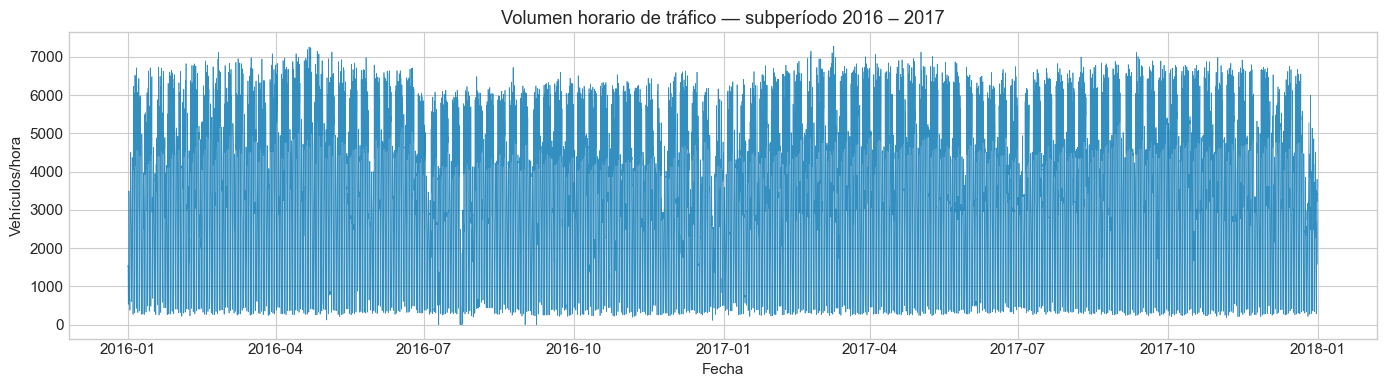

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_sub["date_time"], df_sub["traffic_volume"], linewidth=0.5, alpha=0.8)
ax.set_title("Volumen horario de tráfico — subperíodo 2016 – 2017")
ax.set_xlabel("Fecha")
ax.set_ylabel("Vehículos/hora")
plt.tight_layout()
plt.show()

Similar al caso anterior, se muestran la cantidad de vehículos por hora, pero en este caso para la primer semana de subperíodo de análisis (2016-01-01 a 2016-01-08).

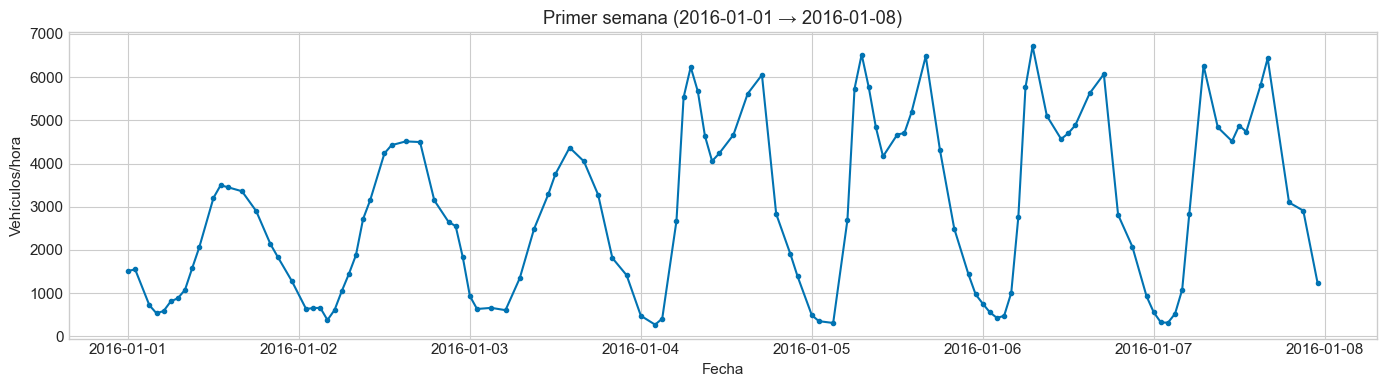

In [27]:
week_start = df_sub["date_time"].min().normalize()
week_end = week_start + pd.Timedelta(days=7)
zoom = df_sub[(df_sub["date_time"] >= week_start) & (df_sub["date_time"] < week_end)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(zoom["date_time"], zoom["traffic_volume"], marker="o", markersize=3)
ax.set_title(f"Primer semana ({week_start.date()} → {week_end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Vehículos/hora")
plt.tight_layout()
plt.show()

A continuación se muestra un gráfico boxplot que contiene la distribución del tráfico por hora del día.

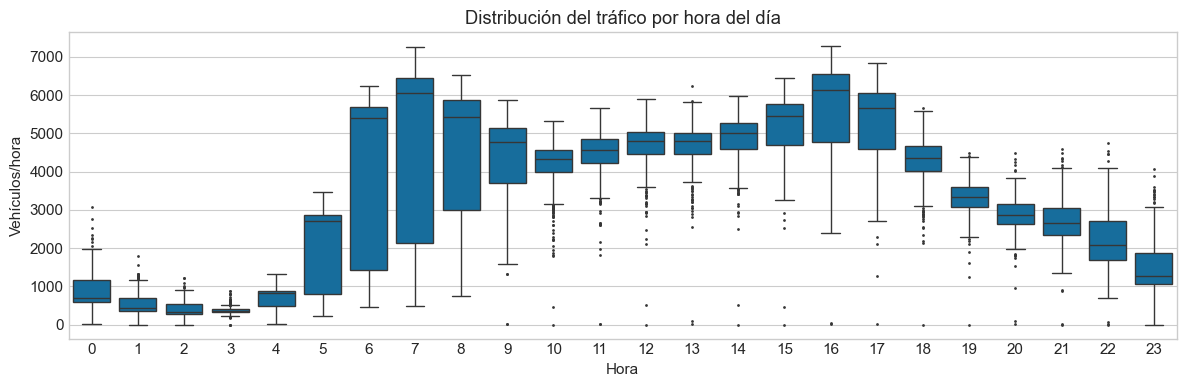

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df_sub, x="hour", y="traffic_volume", ax=ax, fliersize=1)
ax.set_title("Distribución del tráfico por hora del día")
ax.set_xlabel("Hora")
ax.set_ylabel("Vehículos/hora")
plt.tight_layout()
plt.show()

A continuación se muestra un gráfico boxplot que contiene la distribución del tráfico por día de la semana.

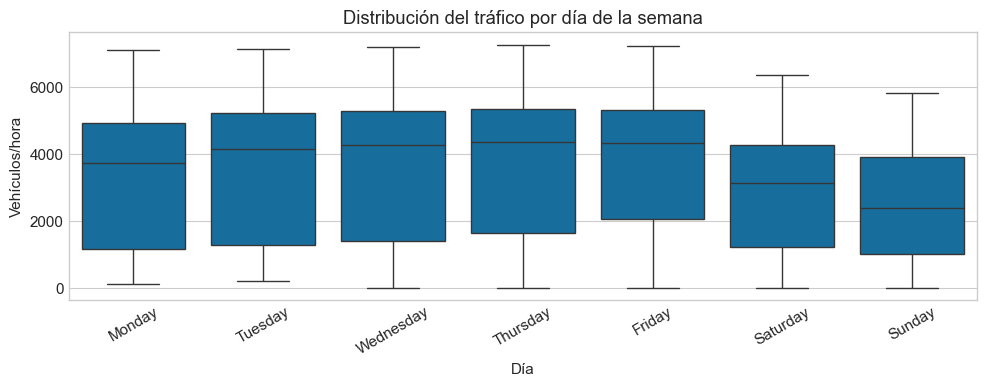

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=df_sub,
    x="weekday",
    y="traffic_volume",
    order=weekday_order,
    ax=ax,
    fliersize=1,
)
ax.set_title("Distribución del tráfico por día de la semana")
ax.set_xlabel("Día")
ax.set_ylabel("Vehículos/hora")
plt.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Finalmente, se muestra un gráfico boxplot que compara el tráfico entre días feriados y no feriados.

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_8532\3187230939.py:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["No feriado", "Feriado"])


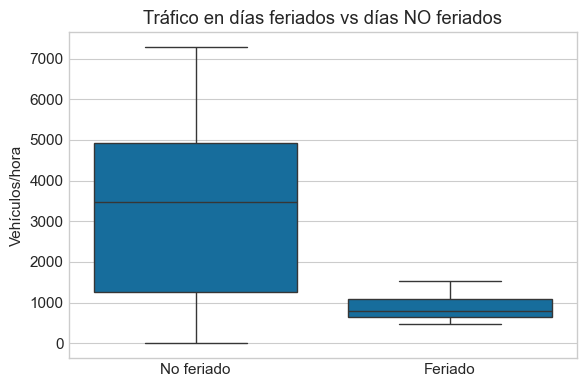

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_sub, x="is_holiday", y="traffic_volume", ax=ax)
ax.set_xticklabels(["No feriado", "Feriado"])
ax.set_title("Tráfico en días feriados vs días NO feriados")
ax.set_xlabel("")
ax.set_ylabel("Vehículos/hora")
plt.tight_layout()
plt.show()

## 1.9 - Patrones iniciales e hipótesis

A partir del análisis anterior se observa:

1. **Hora pico diario (s=24):** picos en horas de entrada/salida laboral (~7–9 h y ~16–18 h).
2. **Estacionalidad semanal:** menor tráfico en fines de semana que en días laborables.
3. **Feriados:** volumen generalmente menor que en días laborables comparables.
4. **Clima:** lluvia/nieve pueden reducir el tráfico. La correlación lineal con `temp` es débil pero se evaluará en SARIMAX.
5. **Calidad temporal:** existen duplicados y huecos horarios; se deduplicó y se documenta para los notebooks siguientes.

Estas hipótesis motivan modelos con estacionalidad diaria (Holt-Winters, SARIMA) y exógenas en SARIMAX.

In [34]:
rush = df_sub[df_sub["hour"].isin([7, 8, 9, 16, 17, 18])]["traffic_volume"].mean()
valley = df_sub[df_sub["hour"].isin([2, 3, 4])]["traffic_volume"].mean()
weekday_mean = df_sub[df_sub["weekday"].isin(weekday_order[:5])]["traffic_volume"].mean()
weekend_mean = df_sub[df_sub["weekday"].isin(weekday_order[5:])]["traffic_volume"].mean()

print(f"Media hora pico (7–9, 16–18 h):   {rush:,.0f}")
print(f"Media valle nocturno (2–4 h):     {valley:,.0f}")
print(f"Media días laborables:            {weekday_mean:,.0f}")
print(f"Media fin de semana:              {weekend_mean:,.0f}")
print(f"Media feriados:                   {df_sub.loc[df_sub['is_holiday'] == 1, 'traffic_volume'].mean():,.0f}")
print(f"Media no feriados:                {df_sub.loc[df_sub['is_holiday'] == 0, 'traffic_volume'].mean():,.0f}")

Media hora pico (7–9, 16–18 h):   4,865
Media valle nocturno (2–4 h):     510
Media días laborables:            3,543
Media fin de semana:              2,662
Media feriados:                   910
Media no feriados:                3,293


## 1.10 - Exportar datos procesados

Artefactos para los notebooks siguientes:
- `traffic_horario.csv`: datetime + traffic_volume
- `exogenas_horarias.csv`: datetime + exógenas

In [36]:
traffic_out = df_sub[["date_time", "traffic_volume"]].copy()
exog_out = df_sub[["date_time", "temp", "rain_1h", "snow_1h", "is_holiday"]].copy()

traffic_path = PROCESSED_DIR / "traffic_horario.csv"
exog_path = PROCESSED_DIR / "exogenas_horarias.csv"

traffic_out.to_csv(traffic_path, index=False)
exog_out.to_csv(exog_path, index=False)

print(f"Guardado: {traffic_path} ({len(traffic_out):,} filas)")
print(f"Guardado: {exog_path} ({len(exog_out):,} filas)")

Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\processed\traffic_horario.csv (16,551 filas)
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\processed\exogenas_horarias.csv (16,551 filas)
